# Educational plots

Plots used for educational purposes, no real data.

Some plots have been created with the help of the UVA AI chat

## Contents
- Explain unfolding

## Detector Effects & the Response Matrix

Detector effects **smear** the data by applying a **response matrix** $R_{ij}$ over the true distribution. The reconstructed bin contents $\nu_i$ are related to the true bin contents $\mu_j$ by:

$$
\nu_i = \sum_{j=1}^{M} R_{ij} \, \mu_j
$$

where the matrix elements are conditional probabilities:

$$
R_{ij} = P(\text{measure in bin } i \mid \text{true in bin } j)
$$

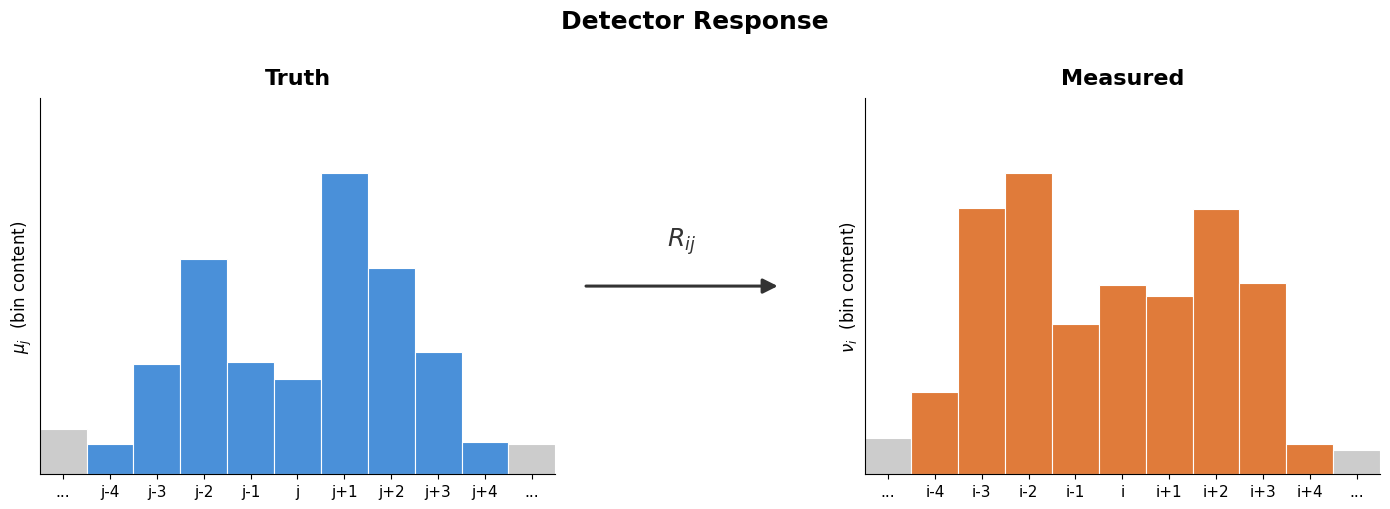

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#ffffff')

# --- Bin labels ---
labels_truth = ['...', 'j-4', 'j-3', 'j-2', 'j-1', 'j', 'j+1', 'j+2', 'j+3', 'j+4', '...']
labels_meas  = ['...', 'i-4', 'i-3', 'i-2', 'i-1', 'i', 'i+1', 'i+2', 'i+3', 'i+4', '...']

# Smooth multi-peak shapes
x_inner = np.linspace(0, 1, 9)
heights_truth_inner = (
    0.6 * np.exp(-((x_inner - 0.25) ** 2) / 0.02) +
    0.9 * np.exp(-((x_inner - 0.65) ** 2) / 0.015) +
    0.3 * np.exp(-((x_inner - 0.85) ** 2) / 0.01)
)
heights_meas_inner = (
    0.85 * np.exp(-((x_inner - 0.20) ** 2) / 0.025) +
    0.5  * np.exp(-((x_inner - 0.55) ** 2) / 0.02) +
    0.75 * np.exp(-((x_inner - 0.80) ** 2) / 0.012)
)

def norm(h):
    return 0.1 + 0.9 * (h - h.min()) / (h.max() - h.min())

heights_truth = [0.15] + list(norm(heights_truth_inner)) + [0.1]
heights_meas  = [0.12] + list(norm(heights_meas_inner))  + [0.08]

x = np.arange(len(labels_truth))

colors_truth = ['#cccccc' if l == '...' else '#4a90d9' for l in labels_truth]
colors_meas  = ['#cccccc' if l == '...' else '#e07b3a' for l in labels_meas]

# --- Truth histogram ---
ax1 = axes[0]
ax1.bar(x, heights_truth, width=1.0, color=colors_truth, edgecolor='white', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(labels_truth, fontsize=11)
ax1.set_title('Truth', fontsize=16, fontweight='bold', pad=10)
ax1.set_ylabel(r'$\mu_j$  (bin content)', fontsize=12)
ax1.set_ylim(0, 1.25)
ax1.set_xlim(-0.5, len(labels_truth) - 0.5)
ax1.set_facecolor('#ffffff')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(left=False, labelleft=False)

# --- Measured histogram ---
ax2 = axes[1]
ax2.bar(x, heights_meas, width=1.0, color=colors_meas, edgecolor='white', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels_meas, fontsize=11)
ax2.set_title('Measured', fontsize=16, fontweight='bold', pad=10)
ax2.set_ylabel(r'$\nu_i$  (bin content)', fontsize=12)
ax2.set_ylim(0, 1.25)
ax2.set_xlim(-0.5, len(labels_meas) - 0.5)
ax2.set_facecolor('#ffffff')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(left=False, labelleft=False)

# --- Finalise layout first ---
plt.suptitle('Detector Response', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(wspace=0.6)


# --- Arrow and label after layout is finalised ---
ax1_pos = ax1.get_position()
ax2_pos = ax2.get_position()

offset = -0.02  # tweak to move arrow+label left (negative) or right (positive)

mid_x = (ax1_pos.x1 + ax2_pos.x0) / 2 + offset
mid_y = (ax1_pos.y0 + ax1_pos.y1) / 2

shrink = 0.03  # increase to shorten the arrow

arrow = mpatches.FancyArrowPatch(
    posA=(ax1_pos.x1 + 0.01 + offset + shrink, mid_y),
    posB=(ax2_pos.x0 - 0.01 + offset - shrink, mid_y),
    transform=fig.transFigure,
    arrowstyle='-|>',
    mutation_scale=22,
    linewidth=2.2,
    color='#333333'
)
fig.add_artist(arrow)

fig.text(mid_x, mid_y + 0.06, r'$R_{ij}$', ha='center', va='bottom',
         fontsize=18, color='#333333', fontweight='bold')

plt.savefig('response_matrix.pdf', dpi=150, bbox_inches='tight')
plt.show()